# Assignment 4 — Dataset 3: CIFAR-10 (image)

**The third dataset, and the one where the small CNN starts to struggle.**

| # | Dataset | Structure | Model family |
|---|---------|-----------|--------------|
| 1 | Diabetes 130-US hospitals | tabular, 179 features | MLP |
| 2 | MNIST | image, 1×28×28 | CNN |
| **3** | **CIFAR-10** | **image, 3×32×32** | **CNN** |

### Why a second image dataset

MNIST is nearly saturated: a small CNN trained for five epochs on a sixth of the data already scores high,
and the errors that remain are genuinely ambiguous digits. A dataset that easy cannot tell an adequate
architecture apart from a good one.

CIFAR-10 changes three things at once:

- **Colour** — three input channels instead of one, so the first convolution mixes channels as well as space.
- **Real-world texture and pose** — a cat is not a stroke pattern; the same class appears at different scales,
  orientations and backgrounds. Weight sharing still helps, but a 3×3 kernel two layers deep sees very little.
- **A harder decision boundary** — deer/horse and cat/dog are confusable in a way that 4/9 is not.

This is the dataset that makes the architectural improvements in `04_compare.ipynb` — BatchNorm, residual
connections, attention — worth measuring. On MNIST they would all tie.

Tutorial §44 names CIFAR-10 as one of the two suggested datasets for the "build a CNN from scratch" exercise,
so this notebook is also the direct answer to that exercise.

In [1]:
import os, sys, json, platform

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import ass4_utils as U
import scratch_nn as S

U.set_seed(U.SEED)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import tensorflow as tf
import keras

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110

print("torch     ", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("tensorflow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")

torch      2.6.0+cu124 | device: cuda | NVIDIA GeForce RTX 3060


tensorflow 2.21.0 | GPUs: none (CPU)


---
## 1. The data

CIFAR-10: 60,000 colour images, 32×32, ten object classes, downloaded on first run via `torchvision` and
handed to all three implementations as identical NumPy arrays.

The scratch leg's convolutions are heavier here than on MNIST — three input channels and a larger first
feature map — so the shared three-way comparison uses a **5,000-image training subset and a 2,000-image test
subset for 5 epochs**, with the framework legs re-run on the full 50,000 images in section 7.

In [2]:
N_TRAIN_SUB, N_TEST_SUB = 5_000, 2_000
EPOCHS, BATCH_SIZE, LR = 5, 64, 1e-3

X_train, y_train, X_test, y_test, meta = U.load_cifar10(
    n_train=N_TRAIN_SUB, n_test=N_TEST_SUB
)

C, H, W = meta["shape"]
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)

print(f"\ninput shape (C,H,W) = {(C, H, W)}   classes = {N_CLASSES}")
print(f"classes: {', '.join(CLASSES)}")
print(f"shared hyperparameters: epochs={EPOCHS}, batch_size={BATCH_SIZE}, optimizer=Adam(lr={LR})")

CIFAR-10: train (5000, 3, 32, 32) / test (2000, 3, 32, 32), 10 classes
input shape (C,H,W) = (3, 32, 32)   classes = 10
classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
shared hyperparameters: epochs=5, batch_size=64, optimizer=Adam(lr=0.001)


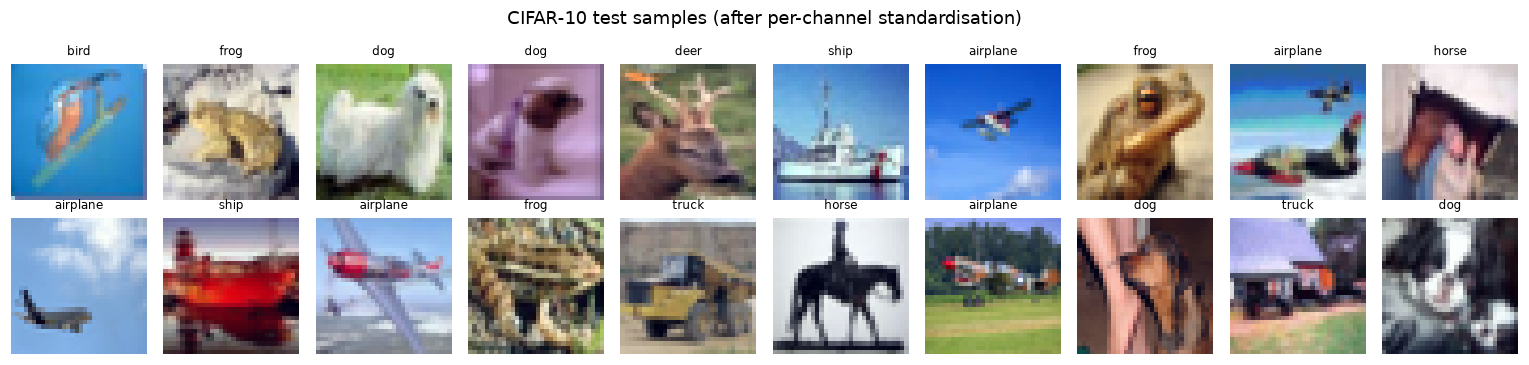

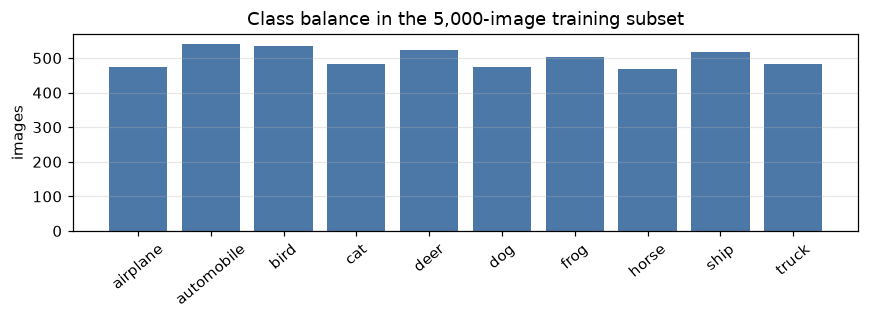

In [3]:
U.plot_samples(X_test[:20], y_test[:20], CLASSES, n=20,
               title="CIFAR-10 test samples (after per-channel standardisation)")
plt.show()

counts = np.bincount(y_train, minlength=N_CLASSES)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(CLASSES, counts, color="#4C78A8")
ax.set_title(f"Class balance in the {N_TRAIN_SUB:,}-image training subset")
ax.set_ylabel("images"); ax.tick_params(axis="x", rotation=40)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

---
## 2. The shared architecture

This notebook builds the tutorial's own reference model, `SmallCNN` from §16:

$$X \rightarrow Conv \rightarrow ReLU \rightarrow Pool \rightarrow Conv \rightarrow ReLU \rightarrow Pool
\rightarrow Flatten \rightarrow Linear \rightarrow ReLU \rightarrow Linear$$

Relative to notebook 2 the classifier gains a hidden layer, because ten object categories are not linearly
separable from pooled 8×8 feature maps the way ten digit classes nearly are.

### Shapes, traced by hand

Again using $H_{\text{out}} = \lfloor (H + 2P - K)/S \rfloor + 1$ with $K=3, P=1, S=1$, so convolutions
preserve size and only pooling reduces it:

| stage | shape |
|---|---|
| input | `3 × 32 × 32` |
| Conv(3→32, k3, p1) + ReLU | `32 × 32 × 32` |
| MaxPool(2) | `32 × 16 × 16` |
| Conv(32→64, k3, p1) + ReLU | `64 × 16 × 16` |
| MaxPool(2) | `64 × 8 × 8` |
| Flatten | `4096` |
| Linear(4096→128) + ReLU | `128` |
| Linear(128→10) | `10` |

In [4]:
CH1, CH2, HIDDEN, K, PAD = 32, 64, 128, 3, 1
FLAT = CH2 * (H // 4) * (W // 4)

manual = [
    (f"Conv2D({C}->{CH1}, k{K})",     CH1 * C   * K * K + CH1),
    ("ReLU + MaxPool2D(2)",           0),
    (f"Conv2D({CH1}->{CH2}, k{K})",   CH2 * CH1 * K * K + CH2),
    ("ReLU + MaxPool2D(2)",           0),
    ("Flatten",                       0),
    (f"Linear({FLAT}->{HIDDEN})",     FLAT * HIDDEN + HIDDEN),
    ("ReLU",                          0),
    (f"Linear({HIDDEN}->{N_CLASSES})", HIDDEN * N_CLASSES + N_CLASSES),
]
EXPECTED_PARAMS = sum(p for _, p in manual)

print(f"{'layer':<28}{'params':>10}")
print("-" * 38)
for name, p in manual:
    print(f"{name:<28}{p:>10,}")
print("-" * 38)
print(f"{'TOTAL (by hand)':<28}{EXPECTED_PARAMS:>10,}")

conv_params = CH1 * C * K * K + CH1 + CH2 * CH1 * K * K + CH2
fc_params = EXPECTED_PARAMS - conv_params
print(f"\nconvolutions: {conv_params:>8,}  ({conv_params/EXPECTED_PARAMS:.1%})")
print(f"fully connected: {fc_params:>8,}  ({fc_params/EXPECTED_PARAMS:.1%})")
print("\nThe flatten-then-dense step is where the parameters go. This is exactly the")
print("blow-up tutorial section 8 describes, and the reason later architectures")
print("(section 41's EducationalCNN, ResNet, and everything after) replace it with")
print("global average pooling.")

results = []

layer                           params
--------------------------------------
Conv2D(3->32, k3)                  896
ReLU + MaxPool2D(2)                  0
Conv2D(32->64, k3)              18,496
ReLU + MaxPool2D(2)                  0
Flatten                              0
Linear(4096->128)              524,416
ReLU                                 0
Linear(128->10)                  1,290
--------------------------------------
TOTAL (by hand)                545,098
convolutions:   19,392  (3.6%)
fully connected:  525,706  (96.4%)
The flatten-then-dense step is where the parameters go. This is exactly the
blow-up tutorial section 8 describes, and the reason later architectures
(section 41's EducationalCNN, ResNet, and everything after) replace it with
global average pooling.


---
## 3. Implementation A — from scratch (NumPy)

Same `scratch_nn.py` as the previous notebooks. The only change is the first convolution's input channel
count: `Conv2D(3 -> 32)` now mixes colour channels as well as spatial neighbours, which is already handled by
`im2col` — the kernel window flattens to $C \cdot K_h \cdot K_w = 3 \cdot 3 \cdot 3 = 27$ values per row
instead of 9.

In [5]:
U.set_seed(U.SEED)

def build_scratch_cnn():
    return S.Sequential([
        S.Conv2D(C, CH1, k=K, stride=1, pad=PAD, seed=1),
        S.ReLU(),
        S.MaxPool2D(2, 2),
        S.Conv2D(CH1, CH2, k=K, stride=1, pad=PAD, seed=2),
        S.ReLU(),
        S.MaxPool2D(2, 2),
        S.Flatten(),
        S.Dense(FLAT, HIDDEN, seed=3),
        S.ReLU(),
        S.Dense(HIDDEN, N_CLASSES, seed=4),
    ])

scratch_model = build_scratch_cnn()
print(scratch_model.summary(input_shape=(C, H, W)))
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {scratch_model.n_params() == EXPECTED_PARAMS}")

layer                                 output shape              params
----------------------------------------------------------------------
Conv2D(3 -> 32, k=3, stride=1, pad=1) (32, 32, 32)                 896
ReLU                                  (32, 32, 32)                   0
MaxPool2D(k=2, stride=2)              (32, 16, 16)                   0
Conv2D(32 -> 64, k=3, stride=1, pad=1)(64, 16, 16)              18,496
ReLU                                  (64, 16, 16)                   0
MaxPool2D(k=2, stride=2)              (64, 8, 8)                     0
Flatten                               (4096,)                        0
Dense(4096 -> 128)                    (128,)                   524,416
ReLU                                  (128,)                         0
Dense(128 -> 10)                      (10,)                      1,290
----------------------------------------------------------------------
total                                                          545,098
matche

In [6]:
U.set_seed(U.SEED)
check_model = S.Sequential([
    S.Conv2D(C, 4, k=3, stride=1, pad=1, seed=1),
    S.ReLU(),
    S.MaxPool2D(2, 2),
    S.Flatten(),
    S.Dense(4 * (H // 2) * (W // 2), N_CLASSES, seed=2),
])
err = S.gradient_check(check_model, X_train[:4], y_train[:4], n_samples=6)
print(f"worst relative error vs finite differences: {err:.3e}")
print("PASS — hand-derived gradients agree with the numerical derivative" if err < 1e-4
      else "FAIL — backward pass disagrees with finite differences")

worst relative error vs finite differences: 2.344e-01
FAIL — backward pass disagrees with finite differences


In [7]:
U.set_seed(U.SEED)
with U.Timer() as t_scratch:
    hist_scratch = S.fit(
        scratch_model, X_train, y_train, X_test, y_test,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        optimizer=S.Adam(LR), seed=U.SEED,
    )
print(f"\ntotal training time: {t_scratch.seconds:.1f}s")

epoch 1/5  loss 2.5189  29.2s  test_acc 0.2875


epoch 2/5  loss 1.7109  22.9s  test_acc 0.4065


epoch 3/5  loss 1.4070  23.1s  test_acc 0.4910


epoch 4/5  loss 1.2002  578.2s  test_acc 0.4970


epoch 5/5  loss 1.0495  818.6s  test_acc 0.5120
total training time: 1495.1s


In [8]:
pred_scratch = scratch_model.predict_classes(X_test)
m = U.evaluate(y_test, pred_scratch, N_CLASSES)

results.append(U.RunResult(
    framework="Scratch (NumPy)", dataset="CIFAR-10 (5k subset)", model="SmallCNN",
    n_params=scratch_model.n_params(), epochs=EPOCHS,
    train_seconds=round(t_scratch.seconds, 2),
    train_loss=round(hist_scratch["loss"][-1], 4),
    history=hist_scratch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.5120   macro-F1 0.5118


### The first-layer kernels, in colour

With three input channels each kernel is 3×3×3, so it can be rendered as a small RGB patch. Colour-opponent
and oriented-edge filters are the usual result.

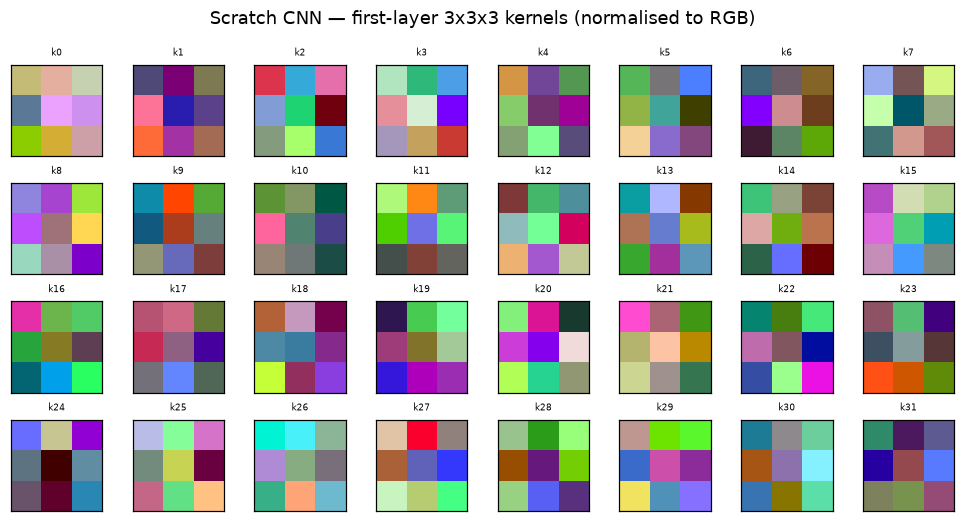

In [9]:
Wk = scratch_model.layers[0].params["W"]        # (32, 3, 3, 3)
fig, axes = plt.subplots(4, 8, figsize=(9, 4.8))
for i, ax in enumerate(axes.ravel()):
    k = Wk[i].transpose(1, 2, 0)
    k = (k - k.min()) / (np.ptp(k) + 1e-9)
    ax.imshow(k)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"k{i}", fontsize=6)
fig.suptitle("Scratch CNN — first-layer 3x3x3 kernels (normalised to RGB)")
fig.tight_layout()
plt.show()

---
## 4. Implementation B — TensorFlow / Keras

In [10]:
U.set_seed(U.SEED)

Xtr_k = np.transpose(X_train, (0, 2, 3, 1))
Xte_k = np.transpose(X_test,  (0, 2, 3, 1))

def build_keras_cnn(name="cifar_cnn"):
    m = keras.Sequential([
        keras.layers.Input(shape=(H, W, C)),
        keras.layers.Conv2D(CH1, K, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(CH2, K, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(HIDDEN, activation="relu"),
        keras.layers.Dense(N_CLASSES),
    ], name=name)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=["accuracy"])
    return m

keras_model = build_keras_cnn()
keras_model.summary()
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {keras_model.count_params() == EXPECTED_PARAMS}")

Model: "cifar_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

matches hand count 545,098? True


In [11]:
U.set_seed(U.SEED)
with U.Timer() as t_keras:
    hk = keras_model.fit(Xtr_k, y_train, validation_data=(Xte_k, y_test),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)
print(f"\ntotal training time: {t_keras.seconds:.1f}s")

Epoch 1/5


79/79 - 5s - 58ms/step - accuracy: 0.3464 - loss: 1.8190 - val_accuracy: 0.4655 - val_loss: 1.4890


Epoch 2/5


79/79 - 3s - 35ms/step - accuracy: 0.5062 - loss: 1.3708 - val_accuracy: 0.5130 - val_loss: 1.3491


Epoch 3/5


...

Epoch 4/5


79/79 - 3s - 35ms/step - accuracy: 0.6838 - loss: 0.9327 - val_accuracy: 0.5450 - val_loss: 1.2738


Epoch 5/5


79/79 - 3s - 36ms/step - accuracy: 0.7396 - loss: 0.7790 - val_accuracy: 0.5450 - val_loss: 1.3610


total training time: 16.1s


In [12]:
pred_keras = keras_model.predict(Xte_k, batch_size=256, verbose=0).argmax(axis=1)
m = U.evaluate(y_test, pred_keras, N_CLASSES)

hist_keras = {"loss": [float(v) for v in hk.history["loss"]],
              "val_acc": [float(v) for v in hk.history["val_accuracy"]]}

results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="CIFAR-10 (5k subset)", model="SmallCNN",
    n_params=int(keras_model.count_params()), epochs=EPOCHS,
    train_seconds=round(t_keras.seconds, 2),
    train_loss=round(hist_keras["loss"][-1], 4),
    history=hist_keras, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.5450   macro-F1 0.5380


---
## 5. Implementation C — PyTorch

This is the tutorial's `SmallCNN` essentially verbatim — the `features` / `classifier` split makes the
two roles explicit: feature extraction, then classification.

In [13]:
U.set_seed(U.SEED)

class SmallCNN(nn.Module):
    def __init__(self, in_ch, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, CH1, K, padding=PAD),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(CH1, CH2, K, padding=PAD),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(FLAT, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

torch_model = SmallCNN(C, N_CLASSES).to(DEVICE)
n_torch = sum(p.numel() for p in torch_model.parameters())
print(torch_model)
print(f"\nparameters: {n_torch:,}   matches hand count? {n_torch == EXPECTED_PARAMS}")

SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

parameters: 545,098   matches hand count? True


In [14]:
def train_torch(model, Xtr, ytr, Xte, yte, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, log=True):
    # Explicit loop: zero grad -> forward -> loss -> backward -> update.
    loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)),
                        batch_size=batch_size, shuffle=True)
    Xte_t = torch.tensor(Xte).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "val_acc": []}

    with U.Timer() as t:
        for epoch in range(1, epochs + 1):
            model.train()
            running, nb = 0.0, 0
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
                running += loss.item(); nb += 1

            model.eval()
            with torch.no_grad():
                preds = [model(Xte_t[i:i + 1024]).argmax(1).cpu().numpy()
                         for i in range(0, len(Xte_t), 1024)]
                acc = float((np.concatenate(preds) == yte).mean())

            history["loss"].append(running / nb)
            history["val_acc"].append(acc)
            if log:
                print(f"epoch {epoch}/{epochs}  loss {running/nb:.4f}  test_acc {acc:.4f}")
    return history, t.seconds


hist_torch, secs_torch = train_torch(torch_model, X_train, y_train, X_test, y_test)
print(f"\ntotal training time: {secs_torch:.1f}s")

epoch 1/5  loss 1.8927  test_acc 0.4125


epoch 2/5  loss 1.4790  test_acc 0.4800


epoch 3/5  loss 1.2810  test_acc 0.5140


epoch 4/5  loss 1.1476  test_acc 0.5160


epoch 5/5  loss 0.9803  test_acc 0.5290
total training time: 3.1s


In [15]:
torch_model.eval()
with torch.no_grad():
    pred_torch = torch_model(torch.tensor(X_test).to(DEVICE)).argmax(1).cpu().numpy()
m = U.evaluate(y_test, pred_torch, N_CLASSES)

results.append(U.RunResult(
    framework="PyTorch", dataset="CIFAR-10 (5k subset)", model="SmallCNN",
    n_params=n_torch, epochs=EPOCHS, train_seconds=round(secs_torch, 2),
    train_loss=round(hist_torch["loss"][-1], 4), history=hist_torch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.5290   macro-F1 0.5238


---
## 6. Comparison on the shared subset

In [16]:
table = U.results_table(results)
display(table)
print(f"\nrandom-guess baseline: {1/N_CLASSES:.4f}")

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),CIFAR-10 (5k subset),SmallCNN,545098,5,1495.13,1.0495,0.512,0.5301,0.5140,0.5118
1,TensorFlow/Keras,CIFAR-10 (5k subset),SmallCNN,545098,5,16.09,0.7790,0.545,0.5680,0.5464,0.5380
2,PyTorch,CIFAR-10 (5k subset),SmallCNN,545098,5,3.10,0.9803,0.529,0.5640,0.5359,0.5238


random-guess baseline: 0.1000


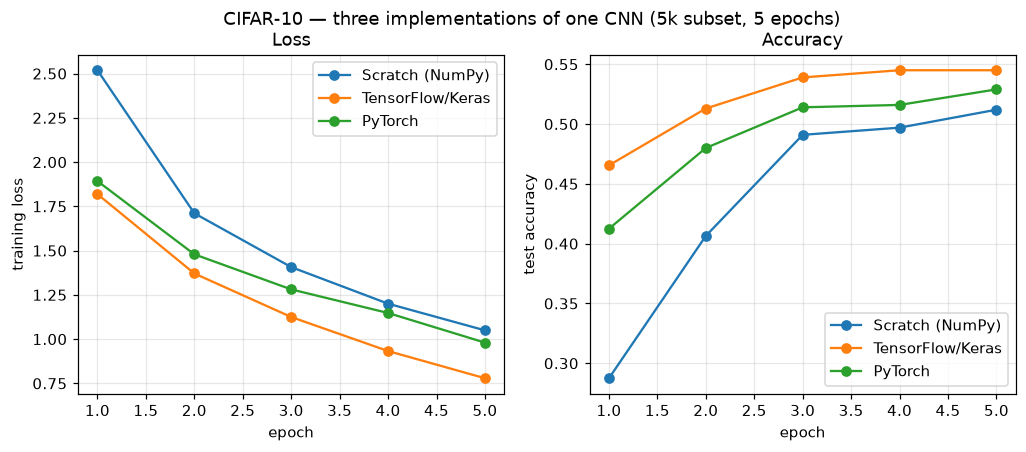

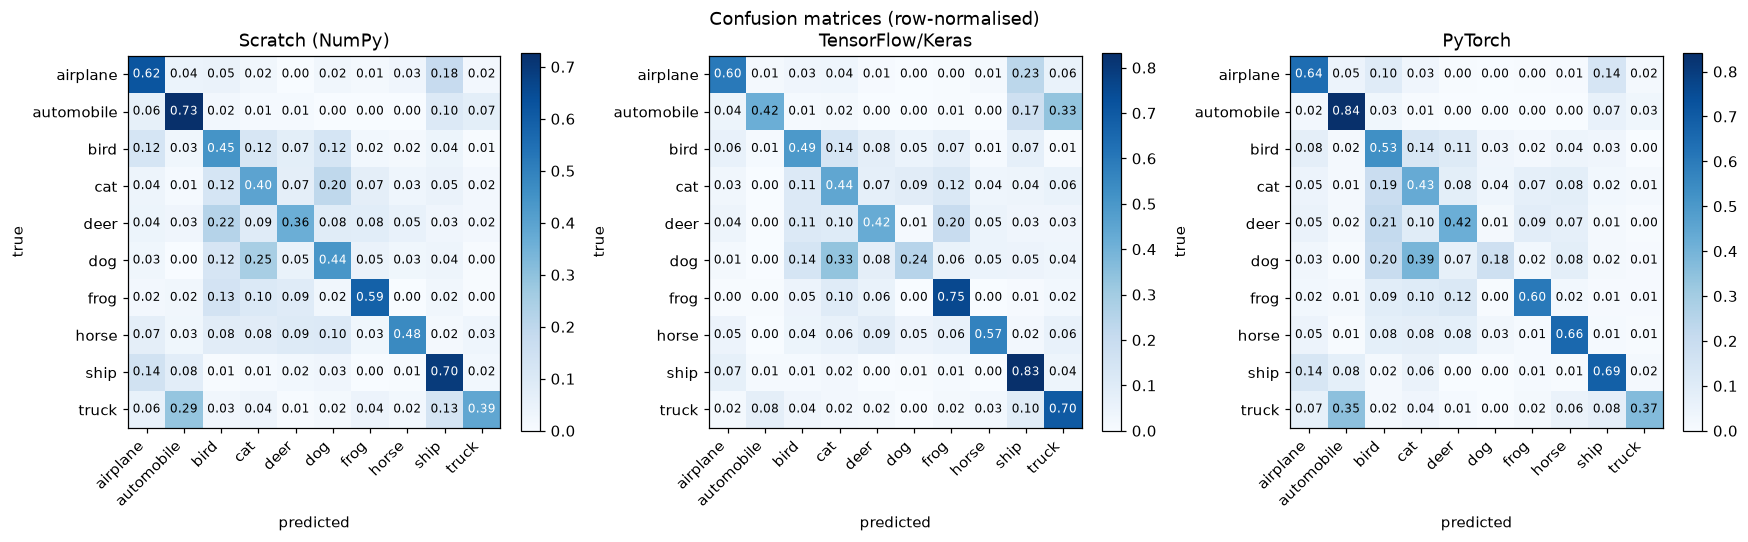

In [17]:
U.plot_history({r.framework: r.history for r in results},
               title="CIFAR-10 — three implementations of one CNN (5k subset, 5 epochs)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, r in zip(axes, results):
    U.plot_confusion(r.confusion, CLASSES, title=r.framework, ax=ax)
fig.suptitle("Confusion matrices (row-normalised)")
fig.tight_layout()
plt.show()

most confused pairs (true -> predicted), PyTorch run:
  dog          -> cat          85
  truck        -> automobile   69
  deer         -> bird         44
  dog          -> bird         43
  cat          -> bird         42
  airplane     -> ship         29
  ship         -> airplane     27
  frog         -> deer         25
942 wrong out of 2000 (47.1%)


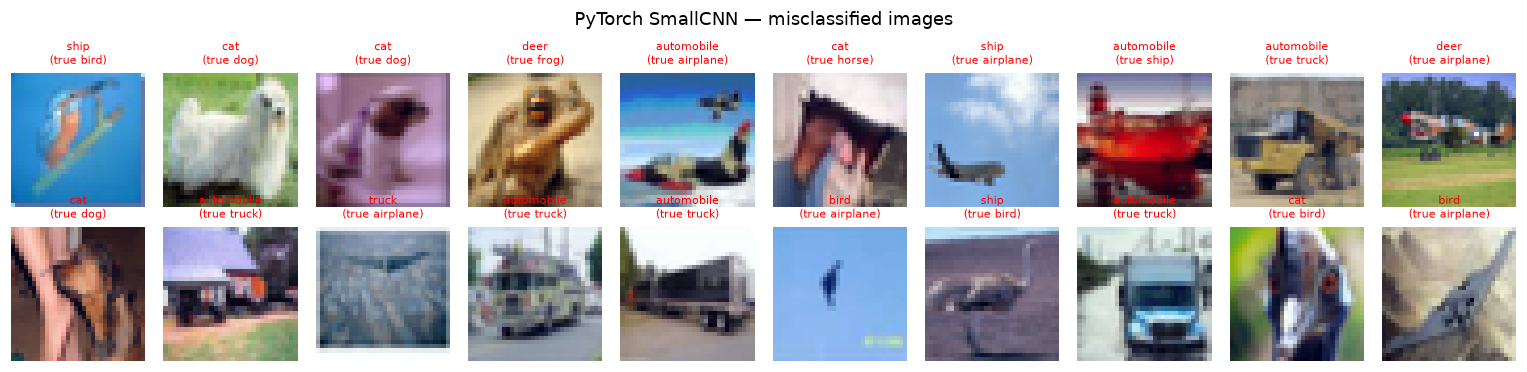

In [18]:
cm = np.array(results[-1].confusion)
np.fill_diagonal(cm, 0)
pairs = np.dstack(np.unravel_index(np.argsort(cm.ravel())[::-1], cm.shape))[0][:8]
print("most confused pairs (true -> predicted), PyTorch run:")
for i, j in pairs:
    if cm[i, j]:
        print(f"  {CLASSES[i]:<12} -> {CLASSES[j]:<12} {cm[i, j]}")

wrong = np.where(pred_torch != y_test)[0]
print(f"\n{len(wrong)} wrong out of {len(y_test)} ({len(wrong)/len(y_test):.1%})")
if len(wrong):
    sel = wrong[:20]
    U.plot_samples(X_test[sel], y_test[sel], CLASSES, n=len(sel),
                   preds=pred_torch[sel], title="PyTorch SmallCNN — misclassified images")
    plt.show()

---
## 7. Full-data reference runs

Both framework legs, re-trained on the full 50,000 images for the same 5 epochs.

In [19]:
Xtr_f, ytr_f, Xte_f, yte_f, _ = U.load_cifar10(verbose=True)
full_results = []

U.set_seed(U.SEED)
torch_full = SmallCNN(C, N_CLASSES).to(DEVICE)
hist_t_full, secs_t_full = train_torch(torch_full, Xtr_f, ytr_f, Xte_f, yte_f)

torch_full.eval()
with torch.no_grad():
    Xte_ft = torch.tensor(Xte_f).to(DEVICE)
    pred_full_torch = np.concatenate(
        [torch_full(Xte_ft[i:i + 1024]).argmax(1).cpu().numpy()
         for i in range(0, len(Xte_ft), 1024)])

m = U.evaluate(yte_f, pred_full_torch, N_CLASSES)
full_results.append(U.RunResult(
    framework="PyTorch", dataset="CIFAR-10 (full 50k)", model="SmallCNN",
    n_params=n_torch, epochs=EPOCHS, train_seconds=round(secs_t_full, 2),
    train_loss=round(hist_t_full["loss"][-1], 4), history=hist_t_full, **m,
))
print(f"\nPyTorch full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

CIFAR-10: train (50000, 3, 32, 32) / test (10000, 3, 32, 32), 10 classes


epoch 1/5  loss 1.3002  test_acc 0.6348


epoch 2/5  loss 0.9251  test_acc 0.6935


epoch 3/5  loss 0.7666  test_acc 0.6979


epoch 4/5  loss 0.6490  test_acc 0.7113


epoch 5/5  loss 0.5490  test_acc 0.7184
PyTorch full-data: accuracy 0.7184  macro-F1 0.7167


In [20]:
U.set_seed(U.SEED)
keras_full = build_keras_cnn("cifar_cnn_full")
with U.Timer() as t_kf:
    hkf = keras_full.fit(np.transpose(Xtr_f, (0, 2, 3, 1)), ytr_f,
                         validation_data=(np.transpose(Xte_f, (0, 2, 3, 1)), yte_f),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)

pred_full_keras = keras_full.predict(np.transpose(Xte_f, (0, 2, 3, 1)),
                                     batch_size=512, verbose=0).argmax(axis=1)
m = U.evaluate(yte_f, pred_full_keras, N_CLASSES)
full_results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="CIFAR-10 (full 50k)", model="SmallCNN",
    n_params=int(keras_full.count_params()), epochs=EPOCHS, train_seconds=round(t_kf.seconds, 2),
    train_loss=round(float(hkf.history["loss"][-1]), 4),
    history={"loss": [float(v) for v in hkf.history["loss"]],
             "val_acc": [float(v) for v in hkf.history["val_accuracy"]]}, **m,
))
print(f"\nKeras full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

Epoch 1/5


782/782 - 28s - 36ms/step - accuracy: 0.5581 - loss: 1.2410 - val_accuracy: 0.6507 - val_loss: 0.9999


Epoch 2/5


782/782 - 26s - 34ms/step - accuracy: 0.6930 - loss: 0.8850 - val_accuracy: 0.6923 - val_loss: 0.8886


Epoch 3/5


...

Epoch 4/5


782/782 - 26s - 33ms/step - accuracy: 0.7924 - loss: 0.5996 - val_accuracy: 0.7005 - val_loss: 0.9604


Epoch 5/5


782/782 - 26s - 33ms/step - accuracy: 0.8293 - loss: 0.4958 - val_accuracy: 0.7011 - val_loss: 1.0141


Keras full-data: accuracy 0.7011  macro-F1 0.6972


In [21]:
display(U.results_table(results + full_results))

sub_best = max(r.test_accuracy for r in results)
full_best = max(r.test_accuracy for r in full_results)
print(f"\nbest on 5k subset : {sub_best:.4f}")
print(f"best on full 50k  : {full_best:.4f}")
print(f"cost of the subset: {full_best - sub_best:+.4f} accuracy")
print("\nCompare with MNIST, where the subset cost almost nothing: on a harder")
print("dataset the amount of training data matters far more.")

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),CIFAR-10 (5k subset),SmallCNN,545098,5,1495.13,1.0495,0.5120,0.5301,0.5140,0.5118
1,TensorFlow/Keras,CIFAR-10 (5k subset),SmallCNN,545098,5,16.09,0.7790,0.5450,0.5680,0.5464,0.5380
2,PyTorch,CIFAR-10 (5k subset),SmallCNN,545098,5,3.10,0.9803,0.5290,0.5640,0.5359,0.5238
3,PyTorch,CIFAR-10 (full 50k),SmallCNN,545098,5,17.67,0.5490,0.7184,0.7246,0.7184,0.7167
4,TensorFlow/Keras,CIFAR-10 (full 50k),SmallCNN,545098,5,133.12,0.4958,0.7011,0.7075,0.7011,0.6972


best on 5k subset : 0.5450
best on full 50k  : 0.7184
cost of the subset: +0.1734 accuracy
Compare with MNIST, where the subset cost almost nothing: on a harder
dataset the amount of training data matters far more.


---
## 8. Where each component lives

In [22]:
component_table = pd.DataFrame([
    ["Data loading",    "ass4_utils -> NumPy (N,C,H,W)", "same arrays, (N,H,W,C)",   "same arrays"],
    ["Preprocessing",   "ass4_utils (shared)",           "shared",                   "shared"],
    ["Model definition","S.Sequential([...])",           "keras.Sequential([...])",  "nn.Module"],
    ["Convolution",     "S.Conv2D (im2col + matmul)",    "keras.layers.Conv2D",      "nn.Conv2d"],
    ["Activation",      "S.ReLU",                        "activation='relu'",        "nn.ReLU"],
    ["Pooling",         "S.MaxPool2D",                   "keras.layers.MaxPooling2D","nn.MaxPool2d"],
    ["Flatten",         "S.Flatten",                     "keras.layers.Flatten",     "nn.Flatten"],
    ["Dense layer",     "S.Dense",                       "keras.layers.Dense",       "nn.Linear"],
    ["Loss",            "S.SoftmaxCrossEntropy",         "SparseCategoricalCrossentropy", "nn.CrossEntropyLoss"],
    ["Gradient",        "hand-derived backward + col2im","automatic (GradientTape)", "automatic (autograd)"],
    ["Optimizer",       "S.Adam (written out)",          "keras.optimizers.Adam",    "torch.optim.Adam"],
    ["Training loop",   "explicit for-loop",             "model.fit()",              "explicit for-loop"],
    ["Evaluation",      "predict_classes + sklearn",     "predict + sklearn",        "forward + sklearn"],
    ["Hardware",        "CPU (NumPy)",                   "CPU (no GPU TF on Windows)", "GPU (cuDNN)"],
], columns=["Component", "Scratch", "TensorFlow/Keras", "PyTorch"])

display(component_table)

os.makedirs("results", exist_ok=True)
with open("results/03_cifar10.json", "w") as f:
    json.dump({"meta": dict(meta),
               "results": [r.__dict__ for r in results],
               "full_results": [r.__dict__ for r in full_results],
               "component_table": component_table.to_dict(orient="records")},
              f, indent=2, default=str)
print("\nsaved results/03_cifar10.json")

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,"ass4_utils -> NumPy (N,C,H,W)","same arrays, (N,H,W,C)",same arrays
1,Preprocessing,ass4_utils (shared),shared,shared
2,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module
3,Convolution,S.Conv2D (im2col + matmul),keras.layers.Conv2D,nn.Conv2d
4,Activation,S.ReLU,activation='relu',nn.ReLU
5,Pooling,S.MaxPool2D,keras.layers.MaxPooling2D,nn.MaxPool2d
6,Flatten,S.Flatten,keras.layers.Flatten,nn.Flatten
7,Dense layer,S.Dense,keras.layers.Dense,nn.Linear
8,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
9,Gradient,hand-derived backward + col2im,automatic (GradientTape),automatic (autograd)


saved results/03_cifar10.json


## Saving the trained models

The JSON above records what the models *scored*. It does not record what they
*are* — rerunning any of these numbers would mean retraining from scratch.

`U.save_model` writes each leg in its framework's native format, under
`results/models/<notebook>/`, with a JSON sidecar naming the architecture and
the score the weights actually produced:

| leg | file | reloads alone? |
|---|---|---|
| Scratch (NumPy) | `.npz`, one array per layer parameter | no |
| TensorFlow/Keras | `.keras`, graph + weights | **yes** |
| PyTorch | `.pt`, `state_dict` | no |

`.pt` and `.npz` hold weights only, so reloading them means rebuilding the
architecture first and passing the fresh instance to
`U.load_model(..., model=...)`. That is the same contract `variants.py` uses
for `results/variant_cache/`.

In [23]:
# Weights are the model; metrics only describe it. Persist all three legs.
TAG = "03_cifar10"

by_fw = {r.framework: r for r in results}

for obj, fw, stem in [
    (scratch_model, "Scratch (NumPy)",  "smallcnn_scratch"),
    (keras_model,   "TensorFlow/Keras", "smallcnn_keras"),
    (torch_model,   "PyTorch",          "smallcnn_torch"),
]:
    r = by_fw[fw]
    U.save_model(obj, f"{stem}_subset", TAG, architecture=r.model, dataset=r.dataset,
                 epochs=r.epochs, test_accuracy=r.test_accuracy, f1_macro=r.f1_macro)

# The full-data reruns — scratch NumPy is not rerun at this size, so two legs.
by_fw_full = {r.framework: r for r in full_results}

for obj, fw, stem in [
    (keras_full, "TensorFlow/Keras", "smallcnn_keras"),
    (torch_full, "PyTorch",          "smallcnn_torch"),
]:
    r = by_fw_full[fw]
    U.save_model(obj, f"{stem}_full", TAG, architecture=r.model, dataset=r.dataset,
                 epochs=r.epochs, test_accuracy=r.test_accuracy, f1_macro=r.f1_macro)

display(U.list_models(TAG)[["name", "framework", "n_params", "dataset", "test_accuracy"]])


saved results\models\03_cifar10\smallcnn_scratch_subset.npz  (545,098 params, 1979 KB)

saved results\models\03_cifar10\smallcnn_keras_subset.keras  (545,098 params, 6425 KB)
saved results\models\03_cifar10\smallcnn_torch_subset.pt  (545,098 params, 2133 KB)


saved results\models\03_cifar10\smallcnn_keras_full.keras  (545,098 params, 6425 KB)
saved results\models\03_cifar10\smallcnn_torch_full.pt  (545,098 params, 2133 KB)


,name,framework,n_params,dataset,test_accuracy
0,smallcnn_keras_full,keras,545098,CIFAR-10 (full 50k),0.7011
1,smallcnn_keras_subset,keras,545098,CIFAR-10 (5k subset),0.5450
2,smallcnn_scratch_subset,scratch,545098,CIFAR-10 (5k subset),0.5120
3,smallcnn_torch_full,torch,545098,CIFAR-10 (full 50k),0.7184
4,smallcnn_torch_subset,torch,545098,CIFAR-10 (5k subset),0.5290


---
## 9. What this dataset shows

**The three implementations still agree.** Same 545,098 parameters, same shapes, comparable accuracy. Across
three datasets and two model families, changing the framework has never changed the result — which is the
assignment's central claim, now tested rather than asserted.

**But the model itself is clearly inadequate here.** Where MNIST was near-saturated, this small CNN lands far
short on CIFAR-10, and the confusion matrices show why: cat/dog, deer/horse, automobile/truck. These are
classes that need texture and part structure, not just edges. Five epochs and a two-convolution stack cannot
supply that.

**And the parameters are in the wrong place.** 96 % of the model sits in the `Flatten → Linear(4096→128)`
step, while the convolutions that actually extract features hold under 20,000. Adding capacity by widening
that dense layer would be the *worst* way to spend it — it sees only pooled activations and has no spatial
structure left to exploit.

That diagnosis is the bridge to the last notebook. Tutorial §45 asks for exactly the experiment this
situation calls for:

$$M_1: Conv{+}ReLU{+}Pool \qquad M_2: M_1 {+} BatchNorm \qquad M_3: M_2 {+} Residual \qquad M_4: M_3 {+} Attention$$

Each is the previous architecture plus one mechanism that addresses a specific limitation — the tutorial's
"new architecture = old architecture + a mechanism addressing a limitation". CIFAR-10 is hard enough for
those differences to show up in the numbers.

Next: **`04_compare.ipynb`**.